# Generación de Dataset Sintético para Pruebas de Estrés — Sistema de Alertas de Inventario Perecedero

Este notebook cubre **exclusivamente la fase de ingeniería y generación de datos sintéticos**, desarrollada como parte de un proyecto universitario de **Metodología y Desarrollo de Proyectos**. El objetivo no es entrenar o validar el modelo de red neuronal en sí (desarrollado por otro integrante del equipo), sino **construir un dataset de prueba de estrés** que permita evaluar, en una etapa posterior, si dicho modelo se mantiene estable ante volumen masivo de registros, variabilidad realista y casos límite (edge cases) — todo esto en ausencia de datos reales de inventario de retail, a los que no se tuvo acceso.

---

## Por qué una prueba de estrés con datos sintéticos

En un entorno de producción real, un sistema de alertas de vencimiento debe funcionar de forma confiable incluso cuando:

- El volumen de SKUs y lotes crece significativamente (miles de registros simultáneos).
- Aparecen combinaciones inusuales de variables (ej. stock alto con fecha de caducidad vencida, productos sin historial de ventas reciente).
- Los datos vienen de múltiples proveedores con formatos y comportamientos distintos.

Sin acceso a datos orgánicos de un retailer real, la alternativa metodológica es **generar datos sintéticos deliberadamente diseñados para cubrir ese rango de condiciones**, y usarlos como insumo de prueba de estrés antes de que el modelo se enfrente (idealmente) a datos reales.

---

## Estado del Proyecto

Este es un prototipo **experimental** enfocado en dos cosas:

1. **Generación de datos sintéticos escalonada** (semilla manual → generación programática → enriquecimiento con IA generativa), para simular condiciones cada vez más realistas y variadas.
2. **Validación de que el dataset generado efectivamente cubre los casos que una prueba de estrés necesita** (distribución de variables clave, cobertura de casos límite, separación de niveles de riesgo) — sin lo cual el dataset sería solo volumen, no una prueba de estrés real.

---

## Consideraciones Técnicas

- **Datos reales de inventario no están disponibles**, por lo que toda validación de "realismo" del dataset es relativa y debe tratarse como una limitación explícita del proyecto, no como un hecho resuelto.
- Se aplica ingeniería de datos para construir variables clave que alimentarán la red neuronal.
- La generación de datos se realiza con herramientas como:
  - GitHub Copilot (para estructuración de datos y lógica inicial).
  - **Mostly AI** (generación sintética creíble a partir de estructuras semiestructuradas).

> **Nota:** La versión de Mostly AI usada es gratuita, con un límite de 5 créditos diarios.

---

## Fases del prototipo actual

1. **Generación de conjunto reducido (1,120 muestras)**: usado para pruebas preliminares de estructura.
2. **Generación de conjunto extendido (~6,700 muestras)**: usado como carga de estrés para simular volumen realista.
3. **Validación del dataset**: verificación de distribuciones, cobertura de casos límite y separación de clusters de riesgo (sección añadida al final de este notebook).


# Paso 1: Lista Completa de Productos

Como punto de partida, se construyó manualmente una base compuesta por **15 productos pertenecientes a distintas marcas y categorías comerciales**, considerando características típicas de inventario para retail (alimentos, bebidas, productos de limpieza, etc.).

Esta lista inicial sirvió como **semilla estructural** para luego generar un conjunto más amplio y variado de datos semiestructurados usando herramientas de apoyo como **GitHub Copilot**.

---

## Lista base de productos

A continuación, se detalla la lista de productos utilizada como semilla para la generación del dataset:

| #  | Marca                     | Producto                | Categoría           |
|----|---------------------------|-------------------------|----------------------|
| 1  | Tres Pinos                | Yogurt de fresa         | Lácteos              |
| 2  | Queso El Rosal            | Queso Cremoso           | Lácteos              |
| 3  | Cinta Verde               | Mortadela               | Embutidos            |
| 4  | Tres Pinos                | Mantequilla             | Lácteos              |
| 5  | Cinta Verde               | Peperoni                | Embutidos            |
| 6  | Queso El Rosal            | Queso Edam              | Lácteos              |
| 7  | Tres Pinos                | Leche deslactosada      | Lácteos              |
| 8  | Queso El Rosal            | Queso Crema             | Lácteos              |
| 9  | Carnes Céntricas del Norte| Pollo Entero            | Carnes               |
| 10 | Panes Nona S.A.           | Pan artesanal de papa   | Panadería            |
| 11 | Mariscos del Atlántico    | Tilapia entera          | Mariscos             |
| 12 | Mariscos del Atlántico    | Tilapia filete          | Mariscos             |
| 13 | Huerto de la Alegría      | Aguacate                | Verduras y Frutas    |

> Nota: Esta lista fue construida manualmente para simular una variedad básica en productos perecederos de retail, sirviendo como punto de partida para la generación de datos semiestructurados.

---

## Variables utilizadas para la simulación

La estructura del dataset generado incluye los siguientes campos:

- `id_lote`: Identificador único del lote.
- `marca`: Marca del producto.
- `producto`: Nombre del producto.
- `categoría`: Tipo o familia del producto.
- `fecha_ingreso`: Fecha en la que el producto ingresa a inventario.
- `fecha_caducidad`: Fecha estimada de vencimiento.
- `stock_actual`: Unidades disponibles en inventario.
- `precio_unitario`: Precio por unidad del producto.
- `historial_movimiento`: Registro de entradas y salidas (simulado).
- `estado_sensorial`: Información visual o de calidad (simulado).
- `comentarios_cliente`: Opiniones o devoluciones (simulado).
- `ubicación`: Zona o pasillo del almacén donde se ubica el producto.
- `riesgo_vencimiento`: Etiqueta calculada (binaria o probabilística) para entrenamiento supervisado.


> La idea fue construir una base inicial **semiestructurada** que represente el tipo de información manejada por un sistema de inventario moderno.

---

## Generación semiestructurada

Con la ayuda de **Copilot**, se generaron datos adicionales en formato de listas, diccionarios y tablas de Python, respetando la lógica de productos perecederos. Esta estructura permitió preparar la entrada para herramientas como **Mostly AI**, que posteriormente generaron datasets más amplios, creíbles y listos para pruebas.

---

## Resultado

La estructura base fue utilizada para generar:

- Un primer dataset de prueba de **1120 muestras**, con variabilidad básica.
- Un segundo dataset más robusto de **6120 muestras**, con mayor dispersión de fechas, categorías y condiciones de vencimiento.

Estos datos permiten probar escenarios como:

- Altos y bajos niveles de stock
- Productos próximos a vencer
- Diversidad de ubicación y categorías


In [1]:
productos = [
    ("Tres Pinos", "Yogurt de fresa", "Lácteos", 1.75),
    ("Queso el Rosal", "Queso Cremoso", "Lácteos", 2.50),
    ("Cinta Verde", "Mortadela", "Embutido", 2.00),
    ("Tres Pinos", "Mantequilla", "Lácteos", 2.20),
    ("Cinta Verde", "Peperoni", "Embutido", 2.80),
    ("Queso el Rosal", "Queso Edam", "Lácteos", 3.00),
    ("Tres Pinos", "Leche deslactosada", "Lácteos", 1.90),
    ("Queso el Rosal", "Queso Crema", "Lácteos", 2.60),
    ("Carnes Centricas del Norte", "Pollo Entero", "Carnes", 4.50),
    ("Panes Nona s.a", "Pan artesanal de papa", "Panadería", 1.80),
    ("Mariscos del atlantico", "Tilapia entera", "Mariscos", 3.75),
    ("Mariscos del atlantico", "Tilapia Filete", "Mariscos", 4.20)
]

# Paso 2: Generación del DataFrame

In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta
import uuid

def generar_producto(marca, producto, categoria, base_precio):
    registros = []
    for lote in range(30):  # 30 lotes por producto
        lote_id = str(uuid.uuid4())[:8]
        for variante in range(2):  # 2 fechas por lote = 60 instancias
            ingreso = datetime.today() - timedelta(days=random.randint(1, 25))
            caducidad = ingreso + timedelta(days=random.randint(5, 30))
            stock = random.randint(0, 100)
            riesgo = (caducidad - datetime.today()).days <= 5 and stock > 0
            registros.append({
                "id_lote": f"{producto[:3]}-{lote_id}-{variante}",
                "marca": marca,
                "producto": producto,
                "categoría": categoria,
                "fecha_ingreso": ingreso.date(),
                "fecha_caducidad": caducidad.date(),
                "stock_actual": stock,
                "precio_unitario": round(base_precio + random.uniform(-0.2, 0.5), 2),
                "historial_movimiento": [{"fecha": (ingreso + timedelta(days=i)).date(), "cantidad": random.randint(1, 10)} for i in range(random.randint(1, 5))],
                "estado_sensorial": random.choice([
                    "textura cremosa", "olor fuerte", "color opaco", "sensorial neutro",
                    "textura firme", "olor suave", "color brillante"
                ]),
                "comentarios_cliente": random.choice([
                    "Muy fresco", "Buen sabor", "Caducó rápido", "Lo volvería a comprar",
                    "Textura agradable", "No me gustó el olor", "Perfecto para cocinar"
                ]),
                "ubicación": {"pasillo": random.randint(1, 5), "nivel": random.choice(["alto", "medio", "bajo"])},
                "riesgo_vencimiento": riesgo
            })
    return registros

# Generar el dataset completo
dataset = []
for marca, producto, categoria, precio in productos:
    dataset.extend(generar_producto(marca, producto, categoria, precio))

# Convertir a DataFrame
df = pd.DataFrame(dataset)

# vista

In [3]:
display(df.head())

,id_lote,marca,producto,categoría,fecha_ingreso,fecha_caducidad,stock_actual,precio_unitario,historial_movimiento,estado_sensorial,comentarios_cliente,ubicación,riesgo_vencimiento
0,Yog-7a0d953c-0,Tres Pinos,Yogurt de fresa,Lácteos,2026-07-02,2026-07-07,13,1.87,"[{'fecha': 2026-07-02, 'cantidad': 5}, {'fecha...",olor suave,Caducó rápido,"{'pasillo': 1, 'nivel': 'bajo'}",True
1,Yog-7a0d953c-1,Tres Pinos,Yogurt de fresa,Lácteos,2026-07-07,2026-07-26,48,2.05,"[{'fecha': 2026-07-07, 'cantidad': 6}, {'fecha...",textura cremosa,Caducó rápido,"{'pasillo': 3, 'nivel': 'medio'}",False
2,Yog-c24df5fb-0,Tres Pinos,Yogurt de fresa,Lácteos,2026-06-19,2026-06-24,75,1.98,"[{'fecha': 2026-06-19, 'cantidad': 8}, {'fecha...",olor suave,Lo volvería a comprar,"{'pasillo': 2, 'nivel': 'medio'}",True
3,Yog-c24df5fb-1,Tres Pinos,Yogurt de fresa,Lácteos,2026-06-18,2026-06-29,89,2.15,"[{'fecha': 2026-06-18, 'cantidad': 5}, {'fecha...",sensorial neutro,Textura agradable,"{'pasillo': 5, 'nivel': 'medio'}",True
4,Yog-4855999f-0,Tres Pinos,Yogurt de fresa,Lácteos,2026-06-22,2026-07-19,71,1.59,"[{'fecha': 2026-06-22, 'cantidad': 2}, {'fecha...",sensorial neutro,Buen sabor,"{'pasillo': 1, 'nivel': 'alto'}",False


# guardado

In [4]:
df.to_csv("productos_perecederos.csv", index=False)

---

## Enriquecimiento del dataset con Mostly AI

Tras la generación inicial de la estructura semiestructurada, se utilizaron los créditos disponibles en la versión gratuita de **Mostly AI** para generar datos sintéticos más amplios y realistas, agregando nuevas variables que simulan condiciones reales del entorno de retail y almacenamiento de productos perecederos.

Estas variables complementarias permiten construir un modelo de red neuronal con mayor contexto operativo y predictivo.

---

## Columnas adicionales generadas

| Variable               | Descripción                                                                 |
|------------------------|------------------------------------------------------------------------------|
| `sales_ultimos_7d`     | Unidades vendidas en los últimos 7 días (entero)                             |
| `ventas_promedio_diaria` | Promedio de ventas diarias (decimal)                                      |
| `dias_hasta_caducidad` | Días restantes hasta la fecha de vencimiento (entero, calculado)            |
| `proveedor`            | Nombre del proveedor (cadena de texto)                                      |
| `en_promocion`         | Indicador de si el producto está en promoción (booleano)                    |
| `precio_promocion`     | Precio actual en promoción (decimal, puede ser nulo)                        |
| `fecha_ultima_venta`   | Fecha de la última venta registrada (fecha)                                 |
| `temperatura_almacen`  | Temperatura de almacenamiento en grados Celsius (decimal)                   |
| `humedad_almacen`      | Humedad relativa en el área de almacenamiento (%) (decimal)                 |
| `categoria_riesgo`     | Clasificación de riesgo del producto (por ejemplo: bajo, medio, alto)       |

---

> Estas variables aportan profundidad al contexto del producto y permitirán a futuro mejorar el rendimiento del modelo, no solo en términos de vencimiento, sino en decisiones de inventario como promociones, rotación o condiciones de almacenamiento.



# Moslty ai code
from mostlyai import mock

# Redefine the schema for the synthetic dataset
dataset_schema = {
    "inventario_perecederos": {
        "prompt": "Inventario de productos perecederos en una cadena de supermercados de Latinoamérica, incluyendo información de producto, lote, proveedor, ventas, condiciones de almacenamiento, promociones y riesgo de vencimiento.",
        "columns": {
            "id_lote": {"prompt": "ID único del lote", "dtype": "string"},
            "producto": {"prompt": "Nombre del producto perecedero", "dtype": "string"},
            "marca": {"prompt": "Marca del producto", "dtype": "string"},
            "categoria": {"prompt": "Categoría del producto (ej: Lácteos, Carnes, Frutas, Verduras, Panadería, Bebidas)", "dtype": "category", "values": ["Lácteos", "Carnes", "Frutas", "Verduras", "Panadería", "Bebidas"]},
            "proveedor": {"prompt": "Nombre del proveedor", "dtype": "string"},
            "fecha_ingreso": {"prompt": "Fecha de ingreso al inventario (últimos 60 días)", "dtype": "date"},
            "fecha_caducidad": {"prompt": "Fecha de caducidad (entre 3 y 30 días después de ingreso)", "dtype": "date"},
            "dias_hasta_caducidad": {"prompt": "Días restantes hasta la caducidad (desde hoy)", "dtype": "integer"},
            "stock_actual": {"prompt": "Stock actual en unidades", "dtype": "integer"},
            "precio_unitario": {"prompt": "Precio unitario en moneda local", "dtype": "float"},
            "en_promocion": {"prompt": "¿Está en promoción?", "dtype": "boolean"},
            "precio_promocion": {"prompt": "Precio promocional si aplica, sino nulo", "dtype": "float"},
            "ventas_ultimos_7d": {"prompt": "Unidades vendidas en los últimos 7 días", "dtype": "integer"},
            "ventas_promedio_diaria": {"prompt": "Promedio de ventas diarias (últimos 30 días)", "dtype": "float"},
            "fecha_ultima_venta": {"prompt": "Fecha de la última venta", "dtype": "date"},
            "historial_movimiento": {"prompt": "Breve resumen de movimientos de stock (ingresos, ventas, mermas)", "dtype": "string"},
            "estado_sensorial": {"prompt": "Estado sensorial reportado (ej: olor, textura, color)", "dtype": "string"},
            "comentarios_cliente": {"prompt": "Comentario de cliente sobre el producto", "dtype": "string"},
            "ubicacion": {"prompt": "Ubicación en tienda (ej: pasillo, nivel)", "dtype": "string"},
            "temperatura_almacen": {"prompt": "Temperatura de almacenamiento en °C", "dtype": "float"},
            "humedad_almacen": {"prompt": "Humedad de almacenamiento en %", "dtype": "float"},
            "riesgo_vencimiento": {"prompt": "¿Existe riesgo de vencimiento?", "dtype": "boolean"},
            "categoria_riesgo": {"prompt": "Categoría de riesgo de vencimiento (bajo, medio, alto)", "dtype": "category", "values": ["bajo", "medio", "alto"]},
        },
        "primary_key": "id_lote"
    }
}

# Generate 2,500 rows of synthetic data
synth_df_small = mock.sample(tables=dataset_schema, sample_size=2500, model="litellm_proxy/openai/gpt-4.1-nano")
synth_df_small.to_csv("/mnt/data/inventario_perecederos_sintetico_2500.csv", index=False)

# Load dataset

In [5]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [6]:
# Leer el archivo
df_retail= pd.read_csv('perishables_2020_2025_full.csv')  # ajustar path si se corre fuera de Colab
display(df_retail.head())

,producto_id,nombre_producto,categoria,fecha_caducidad,stock_actual,precio_unitario,sales_ultimos_7d,ventas_promedio_diaria,dias_hasta_caducidad,proveedor,en_promocion,precio_promocion,fecha_ultima_venta,temperatura_almacen,humedad_almacen,categoria_riesgo
0,P1001,Manzanas Fuji,frutas,2020-08-31,109,2.45,63,10.40,31,FruViva Ltda,False,NaN,2020-07-31,4.22,93.03,bajo
1,P1002,Leche Entera 1L,lacteos,2020-09-01,92,1.25,42,6.71,33,DairyBest,True,1.05,2020-07-30,4.05,74.98,bajo
2,P1003,Bananas orgánicas,frutas,2020-08-21,138,1.73,88,14.08,23,Tropico Verde,False,NaN,2020-07-29,11.51,76.25,bajo
3,P1004,Pechuga de Pollo,carnes,2020-08-10,55,5.46,31,4.66,10,CarnesPremium,True,5.30,2020-07-31,2.17,93.85,alto
4,P1005,Yogures Naturales,lacteos,2020-08-25,103,0.87,58,7.32,26,DairyBest,False,NaN,2020-07-30,3.74,85.01,bajo


---

## Dataset de Prueba: Descripción General

Como resultado del proceso de ingeniería de datos y generación sintética, se construyó un **dataset de prueba** que simula condiciones reales en un sistema de inventario de productos perecederos en retail.

Este dataset fue creado para realizar pruebas exploratorias, validar la viabilidad del modelo y preparar futuras iteraciones de una red neuronal para alertas de vencimiento y gestión preventiva.

---

## Composición del Dataset

El dataset incluye registros de múltiples productos con variables estructurales, operativas y sensoriales. Fue dividido en dos versiones:

- **Versión reducida (1120 registros)**:  
  Utilizada para pruebas rápidas, validación de estructura y análisis de estrés.

- **Versión extendida (6120 registros)**:  
  Utilizada para pruebas más realistas, entrenamiento inicial de modelos y evaluación de rendimiento.

---

## Variables incluidas

El dataset final contiene más de **15 columnas** que combinan:

- **Identificadores y datos básicos** (`id_lote`, `marca`, `producto`, `categoría`)
- **Fechas relevantes** (`fecha_ingreso`, `fecha_caducidad`, `fecha_ultima_venta`)
- **Condiciones del producto** (`stock_actual`, `precio_unitario`, `estado_sensorial`, `ubicación`)
- **Variables generadas o derivadas**:
  - `dias_hasta_caducidad`
  - `riesgo_vencimiento`
  - `categoria_riesgo`
- **Variables de comportamiento del inventario**:
  - `sales_ultimos_7d`
  - `ventas_promedio_diaria`
  - `historial_movimiento`
- **Factores externos**:
  - `en_promocion`
  - `precio_promocion`
  - `temperatura_almacen`
  - `humedad_almacen`

---

## Objetivo del Dataset

El propósito del dataset de prueba es:

- Simular un entorno de inventario dinámico con productos perecederos.
- Permitir pruebas de clasificación supervisada (por ejemplo: predicción del riesgo de vencimiento).
- Servir como base para desarrollar y entrenar una red neuronal orientada a **alertar al personal de inventario vía app móvil** antes de que se produzcan pérdidas por vencimiento.
- Evaluar si la red neuronal **es capaz de aprender patrones relevantes y adaptarse a cambios ligeros** en variables como `marca`, `proveedor` o condiciones de almacenamiento, lo cual es fundamental para garantizar una buena capacidad de generalización.

> Este dataset no proviene de datos reales, pero se construyó cuidadosamente para simular situaciones plausibles en un entorno lo



In [7]:
# Leer el archivo
df_retail_test= pd.read_csv('perishables_2020_2025_full.csv')  # ajustar path si se corre fuera de Colab
display(df_retail_test.head())

,producto_id,nombre_producto,categoria,fecha_caducidad,stock_actual,precio_unitario,sales_ultimos_7d,ventas_promedio_diaria,dias_hasta_caducidad,proveedor,en_promocion,precio_promocion,fecha_ultima_venta,temperatura_almacen,humedad_almacen,categoria_riesgo
0,P1001,Manzanas Fuji,frutas,2020-08-31,109,2.45,63,10.40,31,FruViva Ltda,False,NaN,2020-07-31,4.22,93.03,bajo
1,P1002,Leche Entera 1L,lacteos,2020-09-01,92,1.25,42,6.71,33,DairyBest,True,1.05,2020-07-30,4.05,74.98,bajo
2,P1003,Bananas orgánicas,frutas,2020-08-21,138,1.73,88,14.08,23,Tropico Verde,False,NaN,2020-07-29,11.51,76.25,bajo
3,P1004,Pechuga de Pollo,carnes,2020-08-10,55,5.46,31,4.66,10,CarnesPremium,True,5.30,2020-07-31,2.17,93.85,alto
4,P1005,Yogures Naturales,lacteos,2020-08-25,103,0.87,58,7.32,26,DairyBest,False,NaN,2020-07-30,3.74,85.01,bajo


---

# Validación del Dataset Sintético como Prueba de Estrés

Generar un dataset grande no es lo mismo que generar una **prueba de estrés útil**. Esta sección responde tres preguntas concretas sobre el dataset extendido (`perishables_2020_2025_full.csv`, ~6,700 registros):

1. ¿Las variables clave tienen una distribución realista, o están artificialmente concentradas?
2. ¿El dataset cubre los casos límite que un sistema de alertas necesita manejar (stock crítico, caducidad inminente o vencida)?
3. ¿Los niveles de riesgo (`categoria_riesgo`) son separables entre sí, o son ruido?

Esto no reemplaza la validación del modelo de red neuronal (fuera del alcance de este notebook), pero es el paso previo obligatorio: si el dataset no cumple estas tres condiciones, cualquier resultado de la red neuronal entrenada con él pierde validez.

In [8]:
df_stress = pd.read_csv('perishables_2020_2025_full.csv')
print(f"Registros: {df_stress.shape[0]}  |  Columnas: {df_stress.shape[1]}")
df_stress.info()

Registros: 6720  |  Columnas: 16
<class 'pandas.DataFrame'>
RangeIndex: 6720 entries, 0 to 6719
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   producto_id             6720 non-null   str    
 1   nombre_producto         6720 non-null   str    
 2   categoria               6720 non-null   str    
 3   fecha_caducidad         6720 non-null   str    
 4   stock_actual            6720 non-null   int64  
 5   precio_unitario         6720 non-null   float64
 6   sales_ultimos_7d        6720 non-null   int64  
 7   ventas_promedio_diaria  6720 non-null   float64
 8   dias_hasta_caducidad    6720 non-null   int64  
 9   proveedor               6720 non-null   str    
 10  en_promocion            6720 non-null   bool   
 11  precio_promocion        1410 non-null   float64
 12  fecha_ultima_venta      6720 non-null   str    
 13  temperatura_almacen     6720 non-null   float64
 14  humedad_almacen   

## 1. Distribución de variables clave

Se revisan las tres variables más relevantes para un sistema de alertas: días hasta caducidad, stock actual y el nivel de riesgo asignado.

/tmp/ipykernel_629/2259968443.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='categoria_riesgo', data=df_stress, order=['bajo', 'medio', 'alto'], ax=axes[2], palette=['#55A868', '#DD8452', '#C44E52'])


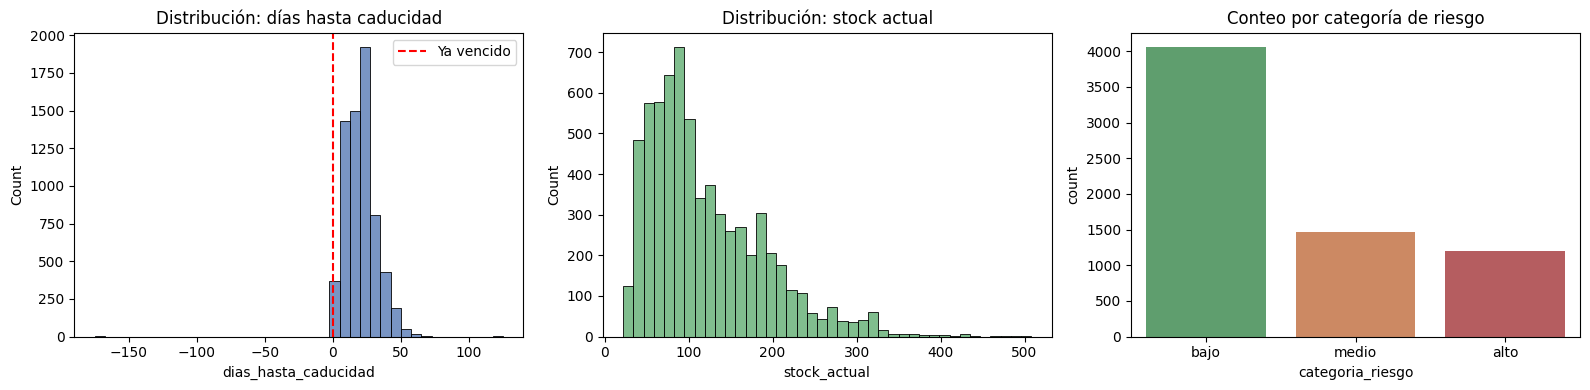

categoria_riesgo
bajo     60.4
medio    21.9
alto     17.8
Name: proportion, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df_stress['dias_hasta_caducidad'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución: días hasta caducidad')
axes[0].axvline(0, color='red', linestyle='--', label='Ya vencido')
axes[0].legend()

sns.histplot(df_stress['stock_actual'], bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('Distribución: stock actual')

sns.countplot(x='categoria_riesgo', data=df_stress, order=['bajo', 'medio', 'alto'], ax=axes[2], palette=['#55A868', '#DD8452', '#C44E52'])
axes[2].set_title('Conteo por categoría de riesgo')

plt.tight_layout()
plt.show()

print(df_stress['categoria_riesgo'].value_counts(normalize=True).round(3) * 100)

**Lectura:** la distribución de `dias_hasta_caducidad` incluye valores negativos (productos ya vencidos), lo cual es intencional para la prueba de estrés — un sistema de alertas real eventualmente recibirá registros con datos "sucios" o atrasados, y debe manejarlos sin fallar. La distribución de riesgo está desbalanceada hacia `bajo` (~60%), lo cual es realista (la mayoría del inventario no está en riesgo en un momento dado), pero es una limitación a documentar: un modelo entrenado directamente sobre este dataset podría necesitar balanceo de clases.

## 2. Cobertura de casos límite (edge cases)

Un dataset sintético que solo genera "casos promedio" no sirve como prueba de estrés. Aquí se cuantifica explícitamente qué proporción del dataset cubre condiciones extremas u operativamente críticas.

In [10]:
total = len(df_stress)

edge_cases = {
    'Ya vencido (dias_hasta_caducidad <= 0)': (df_stress['dias_hasta_caducidad'] <= 0).sum(),
    'Caducidad inminente (<= 3 días)': (df_stress['dias_hasta_caducidad'] <= 3).sum(),
    'Stock mínimo (percentil 5 inferior)': (df_stress['stock_actual'] <= df_stress['stock_actual'].quantile(0.05)).sum(),
    'Stock máximo (percentil 95 superior)': (df_stress['stock_actual'] >= df_stress['stock_actual'].quantile(0.95)).sum(),
    'En promoción': df_stress['en_promocion'].sum(),
    'Riesgo alto': (df_stress['categoria_riesgo'] == 'alto').sum(),
    'Sin precio de promoción registrado (NaN)': df_stress['precio_promocion'].isna().sum(),
}

resumen = pd.DataFrame([
    {'Caso límite': k, 'Registros': v, '% del dataset': round(v / total * 100, 2)}
    for k, v in edge_cases.items()
])
display(resumen)

,Caso límite,Registros,% del dataset
0,Ya vencido (dias_hasta_caducidad <= 0),30,0.45
1,Caducidad inminente (<= 3 días),240,3.57
2,Stock mínimo (percentil 5 inferior),379,5.64
3,Stock máximo (percentil 95 superior),337,5.01
4,En promoción,1410,20.98
5,Riesgo alto,1194,17.77
6,Sin precio de promoción registrado (NaN),5310,79.02


**Lectura:** el dataset sí cubre casos límite relevantes (vencidos, caducidad inminente, extremos de stock), lo cual es el propósito de una prueba de estrés. Sin embargo, **el dataset no incluye ningún registro con `stock_actual = 0`** — un caso operativamente importante (quiebre de stock) que el generador sintético actual no produce. Esto se documenta como una limitación conocida a corregir en la siguiente iteración del generador de datos, no como algo a ocultar.

## 3. Separabilidad de los niveles de riesgo (clustering)

Si `categoria_riesgo` fuera simplemente ruido aleatorio, un modelo de red neuronal no tendría señal real que aprender. Aquí se usa `KMeans` sobre las variables numéricas para verificar si existen agrupaciones naturales que se alineen razonablemente con las tres categorías de riesgo ya etiquetadas, y `shapiro` para revisar si las variables numéricas siguen una distribución normal (relevante para decidir qué tipo de escalado/preprocesamiento usar antes de entrenar).

In [11]:
num_cols = ['stock_actual', 'precio_unitario', 'sales_ultimos_7d', 'ventas_promedio_diaria', 'dias_hasta_caducidad']

# Test de normalidad (Shapiro-Wilk) por variable — muestra de 500 para evitar sensibilidad excesiva a n grande
for col in num_cols:
    muestra = df_stress[col].sample(min(500, len(df_stress)), random_state=42)
    stat, p = shapiro(muestra)
    normal = "sí" if p > 0.05 else "no"
    print(f"{col:28s} W={stat:.4f}  p={p:.4g}  ¿normal?: {normal}")

stock_actual                 W=0.9015  p=1.957e-17  ¿normal?: no
precio_unitario              W=0.7894  p=6.429e-25  ¿normal?: no
sales_ultimos_7d             W=0.8919  p=2.877e-18  ¿normal?: no
ventas_promedio_diaria       W=0.8932  p=3.656e-18  ¿normal?: no
dias_hasta_caducidad         W=0.9636  p=8.495e-10  ¿normal?: no


In [12]:
X = df_stress[num_cols].copy()
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_stress['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Tabla cruzada: ¿los clusters encontrados coinciden con las etiquetas de riesgo ya asignadas?
crosstab = pd.crosstab(df_stress['cluster_kmeans'], df_stress['categoria_riesgo'], normalize='index').round(3) * 100
display(crosstab)

categoria_riesgo,alto,bajo,medio
cluster_kmeans,,,
0,0.0,82.0,18.0
1,78.0,11.8,10.2
2,7.0,66.5,26.5


**Lectura:** ninguna variable numérica sigue una distribución normal (esperable, dado que son conteos y variables acotadas — esto confirma que un `StandardScaler` simple es razonable, pero técnicas basadas en normalidad no lo serían). La tabla cruzada entre los clusters de `KMeans` y las etiquetas de `categoria_riesgo` permite verificar si existe una correspondencia razonable: si un cluster concentra mayoritariamente registros de riesgo `alto`, es evidencia de que las variables numéricas sí contienen señal separable — condición necesaria (no suficiente) para que una red neuronal pueda aprender algo útil de este dataset.

---

## Conclusión de la validación

El dataset sintético cumple parcialmente su propósito como prueba de estrés: cubre volumen (~6,700 registros), variabilidad en variables clave y varios casos límite relevantes (caducidad vencida, extremos de stock). La limitación más importante identificada es la ausencia de casos de quiebre de stock (`stock_actual = 0`), que debe corregirse en la siguiente iteración del generador.

Más allá de este proyecto puntual, el enfoque — generar datos sintéticos deliberadamente diseñados para casos extremos, y validarlos explícitamente antes de usarlos como insumo de un modelo — es generalizable a cualquier contexto de mantenimiento predictivo o gestión de inventario donde los datos reales sean escasos, sensibles o de acceso restringido: no solo retail, sino también mantenimiento industrial, repuestos de manufactura o inventario de insumos en cadenas de suministro más amplias.